# Variable Star Distance

Some pulsating stars follow a **period–luminosity relation**: the longer a star
takes to pulse, the brighter it really is. So if you measure *how fast* it
pulses, you know *how bright* it truly is. Compare that with *how bright it
looks* and you get its distance.

This notebook does that with AAVSO photometry, then checks the answer against
Gaia's parallax distance.

| Step | We compute | From |
|---|---|---|
| 1 | Period $P$ | the observations (Lomb–Scargle periodogram) |
| 2 | Absolute magnitude $M$ | $P$, using a period–luminosity relation |
| 3 | Apparent magnitude $m$ | the observations, folded on $P$ |
| 4 | Dust extinction $A_V$ | a 3D map of interstellar dust |
| 5 | Distance $d$ | $m$, $M$ and $A_V$ |
| Check | Compare with Gaia | Gaia's parallax distance |

## Background: the distance modulus

Light spreads out over a sphere as it travels, so the flux we receive falls off
as $1/d^2$ (the inverse-square law). In magnitudes, that becomes the
**distance modulus**:

$$ m - M = 5\log_{10}(d) - 5 $$

- $m$, the **apparent magnitude**, is how bright the star *looks*. We measure it.
- $M$, the **absolute magnitude**, is how bright it *would* look from 10 parsecs.
  It is a property of the star, and we can't measure it directly.

Solving for distance (in parsecs), and subtracting $A_V$, the dimming caused by
interstellar dust:

$$ d = 10^{\,(m - M - A_V + 5)/5} $$

The hard part is $M$. In 1912 Henrietta Leavitt found that Cepheid variables in
the Small Magellanic Cloud (all at about the same distance) were brighter the
longer their periods were. Each class of pulsating star (classical Cepheids,
SX Phoenicis stars, RR Lyrae, ...) has its own relation, calibrated against stars
with known distances. **Using the right relation for your star matters**: the
wrong one gives a confidently wrong answer.

## Setup

In [1]:
import astronotebooks
astronotebooks.check_environment()   # stops here, with instructions, if Jupyter is using the wrong Python

import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

from astronotebooks import aavso, catalogs, dust, plots, report
from astronotebooks.relations import PL_RELATIONS

environment OK


### Choose a star

Pick one of the sample stars in `photometry/` by setting `STAR`, or add your own:
any AAVSO Extended Format report from VPhot/ASTAP, or a CSV download from the
[AAVSO International Database](https://www.aavso.org/data-download).

Each star needs the period–luminosity relation for its class. Two are available
(see `astronotebooks/relations.py`):

- `SXPhe_CohenSarajedini2012`: SX Phoenicis / short-period pulsators (periods of about 0.02–0.2 days)
- `Cepheid_Benedict2007`: classical Cepheids (about 4–35 days)

In [2]:
TARGETS = {
    # star name: (photometry file, period-luminosity relation)
    "CY Aqr":  ("photometry/CYAqr-09052026/AAVSOReport_CY-Aqr_VBR_110Comp_104Check_TA.txt", "SXPhe_CohenSarajedini2012"),
    "YZ Boo":  ("photometry/YZBoo-08132026/AAVSOReport_YZ-Boo_VRB_20260814_TA.txt", "SXPhe_CohenSarajedini2012"),
    "XX Cyg":  ("photometry/xxcyg.csv", "SXPhe_CohenSarajedini2012"),
    "DY Peg":  ("photometry/dypeg.csv", "SXPhe_CohenSarajedini2012"),
    "del Cep": ("photometry/delCep.csv", "Cepheid_Benedict2007"),
    "eta Aql": ("photometry/etaAql.csv", "Cepheid_Benedict2007"),
}

STAR = "CY Aqr"
BAND = "V"                       # the relations are calibrated in Johnson V
DUST_DIR = ".dustmaps_data"      # where the 3D dust map is stored (Step 4)

REPORT_PATH, RELATION = TARGETS[STAR]
print(f"{STAR}: {REPORT_PATH}")
print(f"relation: {PL_RELATIONS[RELATION]['label']}")

CY Aqr: photometry/CYAqr-09052026/AAVSOReport_CY-Aqr_VBR_110Comp_104Check_TA.txt
relation: SX Phe (Cohen & Sarajedini 2012)


## Load the observations

Read the report and keep the `BAND` measurements. We also look up the star's
catalog period in [VSX](https://www.aavso.org/vsx/) to compare with ours later.

218 V-band points over 0.164 days
VSX catalog period: 0.06103845 days


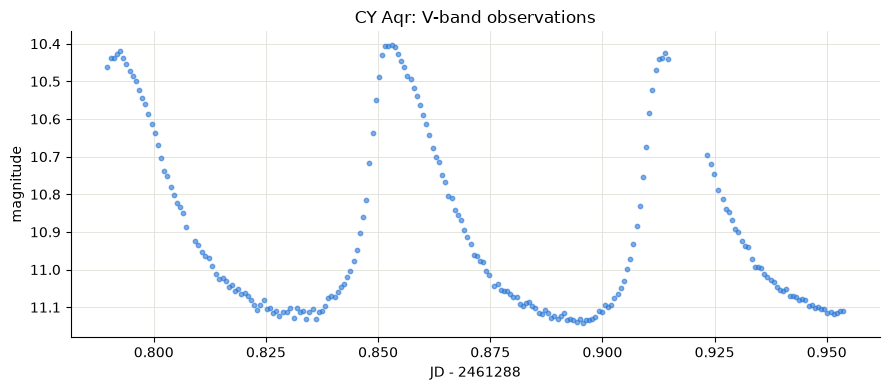

In [3]:
df = aavso.load_aavso_report(REPORT_PATH)
times, mags = aavso.get_band_series(df, BAND)
vsx_period = catalogs.vsx_period(STAR)

print(f"{len(times)} {BAND}-band points over {times.max() - times.min():.3f} days")
print(f"VSX catalog period: {vsx_period} days")

plots.plot_light_curve(times, mags, f"{STAR}: {BAND}-band observations")
plt.show()

## Step 1 · Period from the observations

Real observations are unevenly spaced (clouds, daylight, gaps between nights), so
we use a **Lomb–Scargle periodogram**. It tries many trial periods and scores how
well a repeating wave at each one fits the data. That score is called *power*.
The period with the highest power is our answer.

**The search range.** A period can't be detected unless the data cover at least
about two cycles, so we search from 0.01 days up to half the length of the
observing run. If one night's run is too short to reach the catalog period, we
search ±20% around the catalog period instead.

recovered period: 0.060743 d  (87.5 minutes)
VSX period      : 0.061038 d  (difference -0.43 minutes)


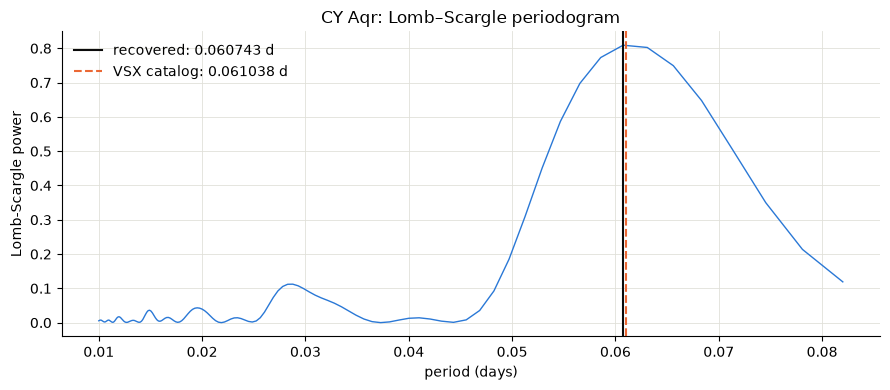

In [4]:
baseline = times.max() - times.min()
p_min, p_max = 0.01, baseline / 2

if vsx_period and vsx_period > p_max:
    p_min, p_max = 0.8 * vsx_period, 1.2 * vsx_period
    print(f"observing run too short to reach the VSX period, searching {p_min:.4f}-{p_max:.4f} d")

frequency, power = LombScargle(times, mags).autopower(
    minimum_frequency=1 / p_max, maximum_frequency=1 / p_min, samples_per_peak=10)
period = 1 / frequency[np.argmax(power)]

print(f"recovered period: {period:.6f} d  ({period * 24 * 60:.1f} minutes)")
if vsx_period:
    print(f"VSX period      : {vsx_period:.6f} d  (difference {(period - vsx_period) * 24 * 60:+.2f} minutes)")

plots.plot_periodogram(1 / frequency, power, period, f"{STAR}: Lomb–Scargle periodogram", vsx_period)
plt.show()

## Step 2 · Absolute magnitude from the period

The period–luminosity relation is a straight line in $\log P$:

$$ M_V = a + b \log_{10}(P) $$

where $a$ (zero-point) and $b$ (slope) come from calibrating stars with known
distances.

The uncertainty on $M$ has two parts:
- **calibration**: how well $a$ and $b$ are known
- **intrinsic scatter**: real stars don't sit exactly on the line. This is usually
  the bigger part, and it sets a floor on how precise any one star's distance can be.

In [5]:
rel = PL_RELATIONS[RELATION]
logP = np.log10(period)

M = rel["a"] + rel["b"] * logP
M_err = np.sqrt(rel["a_err"]**2 + (logP * rel["b_err"])**2 + rel["sigma_intrinsic"]**2)

print(f"relation : {rel['label']}  (a = {rel['a']}, b = {rel['b']})")
print(f"M_V      : {M:.3f} ± {M_err:.3f}")

relation : SX Phe (Cohen & Sarajedini 2012)  (a = -1.64, b = -3.389)
M_V      : 2.483 ± 0.253


## Step 3 · Apparent magnitude from the folded light curve

We need the star's *average* brightness over a cycle. Simply averaging all the
magnitudes is biased in two ways:

1. **Magnitudes are logarithmic.** The average brightness has to be taken in
   flux, then converted back to a magnitude. This is called the *intensity mean*.
2. **The data don't cover the cycle evenly.** If you happened to observe more
   points near minimum, a plain average leans faint.

The fix is to **fold** the data on the period: convert each time to a *phase*
(0 to 1, the fraction of the way through a cycle), sort the points into equal
phase bins, average the flux in each bin, then average the bins. That way every
part of the cycle counts equally.

intensity mean m : 10.871
plain average    : 10.906  (bias +0.035)
phase coverage   : 20 of 20 bins have data


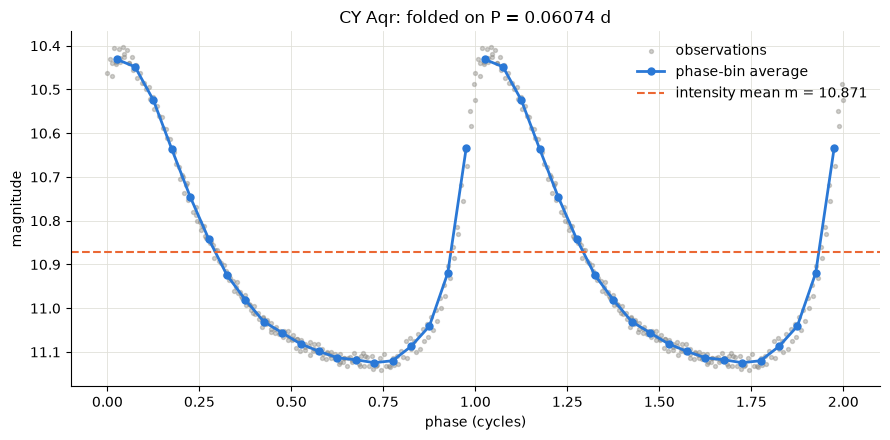

In [6]:
N_BINS = 20

phase = ((times - times.min()) / period) % 1.0
flux = 10 ** (-0.4 * mags)

bins = np.minimum((phase * N_BINS).astype(int), N_BINS - 1)
bin_flux = np.array([flux[bins == b].mean() if np.any(bins == b) else np.nan for b in range(N_BINS)])

m = -2.5 * np.log10(np.nanmean(bin_flux))

print(f"intensity mean m : {m:.3f}")
print(f"plain average    : {mags.mean():.3f}  (bias {mags.mean() - m:+.3f})")
print(f"phase coverage   : {np.sum(~np.isnan(bin_flux))} of {N_BINS} bins have data")

bin_centers = (np.arange(N_BINS) + 0.5) / N_BINS
plots.plot_folded(phase, mags, bin_centers, -2.5 * np.log10(bin_flux), m, f"{STAR}: folded on P = {period:.5f} d")
plt.show()

## Step 4 · Dust along the line of sight

Interstellar dust dims starlight by $A_V$ magnitudes. If we ignore it, the star
looks fainter than it should and we put it **too far away**.

We use **Bayestar19** (Green et al. 2019), a 3D dust map that gives the dust
between us and a given *distance* in a given direction. There's a catch: to look
up the dust we need the distance, and to get the distance we need the dust. So we
**iterate**:

1. Start with the distance assuming no dust.
2. Look up $A_V$ at that distance.
3. Recompute the distance with that $A_V$.
4. Repeat until $A_V$ stops changing.

**One-time setup:** the map is a ~700 MB download. Uncomment the line below and
run it once. Without the map (or on Windows, where the `dustmaps` package isn't
available), the notebook carries on with $A_V = 0$.

In [7]:
# dust.download_bayestar(DUST_DIR)    # uncomment and run once (~700 MB)

In [8]:
coord = catalogs.simbad_coords(STAR)
d = 10 ** ((m - M + 5) / 5)        # starting guess: no dust
A_V, A_V_err = 0.0, 0.0
print(f"start      : d = {d:.0f} pc (no dust)")

for i in range(1, 6):
    new_A_V, new_A_V_err = dust.bayestar_av(coord, d, DUST_DIR)
    if new_A_V is None:
        print("no dust map available, continuing with A_V = 0")
        break
    converged = abs(new_A_V - A_V) <= 0.1 * new_A_V_err   # change is tiny next to the map's own uncertainty
    A_V, A_V_err = new_A_V, new_A_V_err
    d = 10 ** ((m - M - A_V + 5) / 5)
    print(f"iteration {i}: A_V = {A_V:.3f} ± {A_V_err:.3f} mag  ->  d = {d:.0f} pc")
    if converged:
        break

start      : d = 476 pc (no dust)
  loading Bayestar19 dust map (first time only, ~30 s) ...


iteration 1: A_V = 0.247 ± 0.019 mag  ->  d = 425 pc
iteration 2: A_V = 0.247 ± 0.019 mag  ->  d = 425 pc


## Step 5 · Distance

Now put everything into the distance modulus:

$$ d = 10^{\,(m - M - A_V + 5)/5} $$

Because distance depends exponentially on the magnitudes, an uncertainty
$\sigma$ (in magnitudes) becomes a *fractional* distance uncertainty:
$\sigma_d = d \cdot \frac{\ln 10}{5} \cdot \sigma$. Here $\sigma$ combines the
uncertainties on $M$ and $A_V$. The uncertainty on our measured $m$ is small
next to these, so we leave it out.

In [9]:
PC_TO_LY = 3.2616   # light years per parsec


def distance_from_modulus(m, M, M_err, A_V=0.0, A_V_err=0.0):
    d = 10 ** ((m - M - A_V + 5) / 5)
    d_err = d * np.log(10) / 5 * np.hypot(M_err, A_V_err)
    return d, d_err


d_pc, d_err = distance_from_modulus(m, M, M_err, A_V, A_V_err)
d_nodust, _ = distance_from_modulus(m, M, M_err)

print(f"m = {m:.3f},  M = {M:.3f} ± {M_err:.3f},  A_V = {A_V:.3f} ± {A_V_err:.3f}")
print()
print(f"distance            : {d_pc:.0f} ± {d_err:.0f} pc  ({d_pc * PC_TO_LY:.0f} ± {d_err * PC_TO_LY:.0f} light years)")
print(f"ignoring dust gives : {d_nodust:.0f} pc ({100 * (d_nodust - d_pc) / d_pc:+.1f}%)")

m = 10.871,  M = 2.483 ± 0.253,  A_V = 0.247 ± 0.019

distance            : 425 ± 50 pc  (1386 ± 162 light years)
ignoring dust gives : 476 pc (+12.1%)


## Check against Gaia

The Gaia spacecraft measures distance directly by **parallax**: the small shift
in a star's position as Earth orbits the Sun. It's pure geometry, with no period
or brightness involved, so it is an independent check. We use the Bailer-Jones
distance, which handles noisy parallaxes better than simply taking 1/parallax.

Gaia also lets us test the relation itself. Using Gaia's distance and our $m$, we
can solve the distance modulus *backwards* for an independent $M$:

$$ M_{\text{Gaia}} = m - 5\log_{10}(d_{\text{Gaia}}) + 5 - A_V $$

If the star belongs to the class we assumed, $M_{\text{Gaia}}$ should land within
the relation's uncertainty band on the plot below.

In [10]:
gaia = catalogs.gaia_distance(STAR)
M_gaia = M_gaia_err = None

if gaia:
    M_gaia = m - 5 * np.log10(gaia["d_pc"]) + 5 - A_V
    M_gaia_err = np.hypot(5 / np.log(10) * gaia["d_err_pc"] / gaia["d_pc"], A_V_err)

report.variable_star_summary(period, vsx_period, m, M, M_err, d_pc, d_err,
                             gaia, M_gaia, M_gaia_err, band=BAND)

Quantity,This notebook,Catalog,Difference,Check
Period,0.060743 d,0.061038 d (VSX),-0.43 min,
Apparent mag m (V),10.871,11.001 (Gaia G),-0.129,rough only: different band
Absolute mag M,2.483 ± 0.253,2.546 ± 0.026 (Gaia),-0.063,agree
Distance (pc),425 ± 50,413 ± 4 (Gaia),+12 (+2.9%),agree
Distance (light years),1386 ± 162,1346 ± 11 (Gaia),,agree


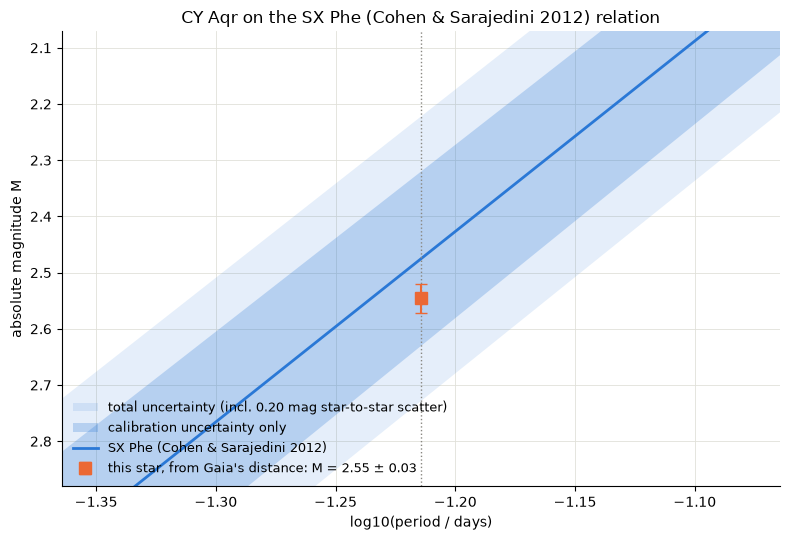

In [11]:
if gaia:
    plot_period = vsx_period or period   # place the star at its catalog period
    plots.plot_pl_relation(rel, plot_period, M_gaia, M_gaia_err, "this star, from Gaia's distance",
                           title=f"{STAR} on the {rel['label']} relation")
    plt.show()
else:
    print("Gaia unavailable right now. Try re-running this cell later.")